<a href="https://colab.research.google.com/github/kir0ul/neural-processes/blob/master/conditional_neural_process_jax.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Copyright 2018 Google LLC

Licensed under the Apache License, Version 2.0 (the "License");
you may not use this file except in compliance with the License.
You may obtain a copy of the License at

 [https://www.apache.org/licenses/LICENSE-2.0](https://www.apache.org/licenses/LICENSE-2.0)

Unless required by applicable law or agreed to in writing, software
distributed under the License is distributed on an "AS IS" BASIS,
WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
See the License for the specific language governing permissions and
limitations under the License.


# Conditional Neural Processes (CNP) for 1D regression. [JAX version]

[Conditional Neural Processes](https://arxiv.org/pdf/1807.01613.pdf) (CNPs) were
introduced as a continuation of
[Generative Query Networks](https://deepmind.com/blog/neural-scene-representation-and-rendering/)
(GQN) to extend its training regime to tasks beyond scene rendering, e.g. to
regression and classification.

In contrast to most standard neural networks, CNPs learn to approximate a
distribution over functions rather than approximating just a single function. As a result, at
test time CNPs are flexible and can approximate any function from this
distribution when provided with a handful of observations. In addition, they
learn to estimate the uncertainty of their prediction from the dataset and as
the number of observations is increased this uncertainty reduces and the
accuracy of their prediction increases.

In this notebook we describe the different parts of a CNP and apply the
resulting model to a 1D regression task where a CNP is trained on a dataset of
random functions.

This is a **JAX** port of the original TensorFlow 1 notebook. The model is
implemented as pure functions operating on parameter pytrees, gradients are
computed with `jax.grad`, and training uses `optax.adam` in place of
`tf.train.AdamOptimizer`.

Any thoughts or questions? We'd love any feedback (about this notebook or CNPs
in general) so just contact us at garnelo@google.com.


## Implementing CNPs

We start by importing the necessary dependencies. We will make use of jax,
optax, numpy, and matplotlib. Requires `pip install jax optax`.


In [1]:
import collections
import jax
# Use double precision for the Cholesky decomposition in the GP sampler, as
# in the original TF1 notebook (`tf.cast(..., tf.float64)`).
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import numpy as np
import optax
import matplotlib.pyplot as plt


## Training data

A crucial property of CNPs is their flexibility at test time, as they can model
a whole range of functions and narrow down their prediction as we condition on
an increasing number of context observations. This behaviour is a result of the
training regime of CNPs which is reflected in our datasets.

![](https://bit.ly/2O2Lq8c)

Rather than training using observations from a single function as it is often
the case in machine learning (for example value functions in reinforcement
learning) we will use a dataset that consists of many different functions that
share some underlying characteristics. This is visualized in the figure above.
The example on the left corresponds to a classic training regime: we have a
single underlying ground truth function (eg. our value function for an agent) in
grey and at each learning iteration we are provided with a handful of examples from this
function that we have visualized in different colours for batches of different
iterations. On the right we show an example of a dataset that could be used for
training neural processes. Instead of a single function, it consists of a large number of functions of a function-class that we are interested in modeling. At each iteration we randomly choose one from the dataset and provide some observations from that function for training. For the next iteration we put that function back and
pick a new one from our dataset and use this new function to select the training
data. This type of dataset ensures that our model can't overfit to a single
function but rather learns a distribution over functions. This idea of a
hierarchical dataset also lies at the core of current meta-learning methods.
Examples of such datasets could be:

*  Functions describing the evolution of temperature over time in different cities
of the world.
*  A dataset of functions generated by a motion capture sensor of different humans
    walking.
*   As in this particular example differents functions generated by a


## Data generator

In the following section we provide the code for generating our training and
testing sets using a GP to generate a dataset of functions. As we will explain
later, CNPs use two subset of points at every iteration: one to serve as the
context, and the other as targets. In practise we found that including the
context points as targets together with some additional new points helped during
training. Our data generator divides the generated data into these two groups
and provides it in the correct format.

**JAX note:** `tf.random_uniform` for choosing the *number* of context/target
points is replaced with `jax.random.randint` and converted to a Python `int`.
JAX requires array shapes to be static (known at trace time), so unlike the
graph-mode TF1 version we cannot keep `num_context`/`num_target` as traced
tensors; they are resolved to concrete Python ints before we build the
arrays. The GP math itself (kernel, Cholesky, sampling) is otherwise a
direct translation to `jax.numpy`, and randomness is threaded explicitly
through `jax.random.PRNGKey` splits instead of TF1's implicit global RNG.


In [2]:
# The CNP takes as input a `CNPRegressionDescription` namedtuple with fields:
#   `query`: a tuple containing ((context_x, context_y), target_x)
#   `target_y`: an array containing the ground truth for the targets to be
#     predicted
#   `num_total_points`: A scalar that describes the total
#     number of datapoints used (context + target)
#   `num_context_points`: A scalar that describes the number
#     of datapoints used as context
# The GPCurvesReader returns the newly sampled data in this format at each
# iteration

CNPRegressionDescription = collections.namedtuple(
    "CNPRegressionDescription",
    ("query", "target_y", "num_total_points", "num_context_points"))


class GPCurvesReader(object):
  """Generates curves using a Gaussian Process (GP).

  Supports vector inputs (x) and vector outputs (y). Kernel is
  mean-squared exponential, using the x-value l2 coordinate distance scaled by
  some factor chosen randomly in a range. Outputs are independent gaussian
  processes.
  """

  def __init__(self,
               batch_size,
               max_num_context,
               x_size=1,
               y_size=1,
               l1_scale=0.4,
               sigma_scale=1.0,
               testing=False):
    """Creates a regression dataset of functions sampled from a GP.

    Args:
      batch_size: An integer.
      max_num_context: The max number of observations in the context.
      x_size: Integer >= 1 for length of "x values" vector.
      y_size: Integer >= 1 for length of "y values" vector.
      l1_scale: Float; typical scale for kernel distance function.
      sigma_scale: Float; typical scale for variance.
      testing: Boolean that indicates whether we are testing. If so there are
          more targets for visualization.
    """
    self._batch_size = batch_size
    self._max_num_context = max_num_context
    self._x_size = x_size
    self._y_size = y_size
    self._l1_scale = l1_scale
    self._sigma_scale = sigma_scale
    self._testing = testing

  def _gaussian_kernel(self, xdata, l1, sigma_f, sigma_noise=2e-2):
    """Applies the Gaussian kernel to generate curve data.

    Args:
      xdata: Array with shape `[batch_size, num_total_points, x_size]` with
          the values of the x-axis data.
      l1: Array with shape `[batch_size, y_size, x_size]`, the scale
          parameter of the Gaussian kernel.
      sigma_f: Array with shape `[batch_size, y_size]`; the magnitude
          of the std.
      sigma_noise: Float, std of the noise that we add for stability.

    Returns:
      The kernel, a float array with shape
      `[batch_size, y_size, num_total_points, num_total_points]`.
    """
    num_total_points = xdata.shape[1]

    # Expand and take the difference
    xdata1 = xdata[:, None, :, :]  # [B, 1, num_total_points, x_size]
    xdata2 = xdata[:, :, None, :]  # [B, num_total_points, 1, x_size]
    diff = xdata1 - xdata2  # [B, num_total_points, num_total_points, x_size]

    # [B, y_size, num_total_points, num_total_points, x_size]
    norm = jnp.square(diff[:, None, :, :, :] / l1[:, :, None, None, :])

    norm = jnp.sum(norm, axis=-1)  # [B, data_size, num_total_points, num_total_points]

    # [B, y_size, num_total_points, num_total_points]
    kernel = jnp.square(sigma_f)[:, :, None, None] * jnp.exp(-0.5 * norm)

    # Add some noise to the diagonal to make the cholesky work.
    kernel = kernel + (sigma_noise**2) * jnp.eye(num_total_points)

    return kernel

  def generate_curves(self, key):
    """Builds the arrays delivering the data.

    Generated functions are `float32` with x values between -2 and 2.

    Args:
      key: A `jax.random.PRNGKey` used to draw this batch.

    Returns:
      A `CNPRegressionDescription` namedtuple.
    """
    key, num_context_key, num_target_key, x_key, y_key, shuffle_key = (
        jax.random.split(key, 6))

    num_context = int(
        jax.random.randint(num_context_key, (), 3, self._max_num_context + 1))

    # If we are testing we want to have more targets and have them evenly
    # distributed in order to plot the function.
    if self._testing:
      num_target = 400
      x_values = jnp.tile(
          jnp.arange(-2., 2., 1. / 100, dtype=jnp.float32)[None, :],
          (self._batch_size, 1))
      x_values = x_values[..., None]
    # During training the number of target points and their x-positions are
    # selected at random
    else:
      num_target = int(
          jax.random.randint(num_target_key, (), 2, self._max_num_context + 1))
      num_total_points = num_context + num_target
      x_values = jax.random.uniform(
          x_key, (self._batch_size, num_total_points, self._x_size),
          minval=-2, maxval=2)

    # Set kernel parameters
    l1 = (
        jnp.ones(shape=(self._batch_size, self._y_size, self._x_size)) *
        self._l1_scale)
    sigma_f = jnp.ones(
        shape=(self._batch_size, self._y_size)) * self._sigma_scale

    # Pass the x_values through the Gaussian kernel
    # [batch_size, y_size, num_total_points, num_total_points]
    kernel = self._gaussian_kernel(x_values, l1, sigma_f)

    # Calculate Cholesky, using double precision for better stability:
    cholesky = jnp.linalg.cholesky(kernel.astype(jnp.float64)).astype(jnp.float32)

    # Sample a curve
    # [batch_size, y_size, num_total_points, 1]
    y_values = jnp.matmul(
        cholesky,
        jax.random.normal(
            y_key, (self._batch_size, self._y_size, x_values.shape[1], 1)))

    # [batch_size, num_total_points, y_size]
    y_values = jnp.transpose(jnp.squeeze(y_values, axis=3), (0, 2, 1))

    if self._testing:
      # Select the targets
      target_x = x_values
      target_y = y_values

      # Select the observations
      idx = jax.random.permutation(shuffle_key, num_target)
      context_x = x_values[:, idx[:num_context], :]
      context_y = y_values[:, idx[:num_context], :]

    else:
      # Select the targets which will consist of the context points as well as
      # some new target points
      target_x = x_values[:, :num_target + num_context, :]
      target_y = y_values[:, :num_target + num_context, :]

      # Select the observations
      context_x = x_values[:, :num_context, :]
      context_y = y_values[:, :num_context, :]

    query = ((context_x, context_y), target_x)

    return CNPRegressionDescription(
        query=query,
        target_y=target_y,
        num_total_points=target_x.shape[1],
        num_context_points=num_context)


## Conditional Neural Processes

We can visualise a forward pass in a CNP as follows:

<img src="https://bit.ly/2OFb6ZK" alt="drawing" width="400"/>

As shown in the diagram, CNPs take in pairs **(x, y)<sub>i</sub>** of context
points, pass them through an **encoder** to obtain
individual representations **r<sub>i</sub>** which are combined using an **aggregator**. The resulting representation **r**
is then combined with the locations of the targets **x<sub>T</sub>** and passed
through a **decoder** that returns a mean estimate
of the **y** value at that target location together with a measure of the
uncertainty over said prediction. Implementing CNPs therefore involves coding up
the three main building blocks:

*   Encoder
*   Aggregator
*   Decoder

A more detailed description of these three parts is presented in the following
sections alongside the code.

**JAX note:** Rather than `tf.layers.dense` under a `tf.variable_scope`, the
encoder and decoder below are plain functions that take an explicit list of
per-layer `{"w", "b"}` parameters (a pytree) and return the transformed
array. Parameters are created once with `init_mlp_params` and threaded
through every call, and updated by `jax.grad`/`optax` rather than mutated
in-place by a TF1 `Session`.


In [3]:
def init_mlp_params(key, output_sizes, input_size):
  """Initialises the weights/biases for a simple feedforward MLP.

  Args:
    key: A `jax.random.PRNGKey`.
    output_sizes: An iterable containing the output sizes of each layer.
    input_size: Integer size of the input feature dimension.

  Returns:
    A list of `{"w": ..., "b": ...}` dicts, one per layer.
  """
  params = []
  in_size = input_size
  for size in output_sizes:
    key, subkey = jax.random.split(key)
    w = jax.random.normal(subkey, (in_size, size)) * jnp.sqrt(2.0 / in_size)
    b = jnp.zeros((size,))
    params.append({"w": w, "b": b})
    in_size = size
  return params


def mlp_forward(params, x):
  """Applies a feedforward MLP (ReLu hidden layers, linear output)."""
  for layer in params[:-1]:
    x = jax.nn.relu(x @ layer["w"] + layer["b"])
  last = params[-1]
  x = x @ last["w"] + last["b"]
  return x


def encoder_forward(params, context_x, context_y):
  """Encodes the context inputs into one representation.

  Args:
    params: The encoder MLP parameters, as returned by `init_mlp_params`.
    context_x: Array of size bs x observations x m_ch. For this 1D regression
        task this corresponds to the x-values.
    context_y: Array of size bs x observations x d_ch. For this 1D regression
        task this corresponds to the y-values.

  Returns:
    representation: The encoded representation averaged over all context
        points.
  """
  # Concatenate x and y along the filter axes
  encoder_input = jnp.concatenate([context_x, context_y], axis=-1)

  # Get the shapes of the input and reshape to parallelise across observations
  batch_size, num_context_points, filter_size = encoder_input.shape
  hidden = encoder_input.reshape((batch_size * num_context_points, filter_size))

  # Pass through MLP
  hidden = mlp_forward(params, hidden)

  # Bring back into original shape
  hidden = hidden.reshape((batch_size, num_context_points, -1))

  # Aggregator: take the mean over all points
  representation = jnp.mean(hidden, axis=1)

  return representation


## Decoder

Once we have obtained our representation **r** we concatenate it with each of
the targets **x<sub>t</sub>** and pass it through the decoder **d**. As with the
encoder **e**, the decoder **d** is shared between all the target points and
consists of a small MLP with layer sizes defined in **`decoder_output_sizes`**.
The decoder outputs a mean **&mu;<sub>t</sub>** and a variance
**&sigma;<sub>t</sub>** for each of the targets **x<sub>t</sub>**. To train our
CNP we use the log likelihood of the ground truth value **y<sub>t</sub>** under
a Gaussian parametrized by these predicted **&mu;<sub>t</sub>** and
**&sigma;<sub>t</sub>**.

In this implementation we clip the variance **&sigma;<sub>t</sub>** at 0.1 to
avoid collapsing.

**JAX note:** `tfp`/`tf.contrib.distributions.MultivariateNormalDiag` is not
part of core JAX, so the decoder now returns `(mu, sigma)` directly and a
small `diag_gaussian_log_prob` helper (defined in the model section below)
computes the equivalent diagonal-Gaussian log density.


In [4]:
def decoder_forward(params, representation, target_x):
  """Decodes the individual targets.

  Args:
    params: The decoder MLP parameters, as returned by `init_mlp_params`.
    representation: The encoded representation of the context.
    target_x: The x locations for the target query.

  Returns:
    mu: The mean of the predicted (diagonal) Gaussian, one per target.
    sigma: The standard deviation of the predicted Gaussian, one per target.
  """
  batch_size, num_total_points, _ = target_x.shape

  # Concatenate the representation and the target_x
  representation = jnp.tile(representation[:, None, :], (1, num_total_points, 1))
  inp = jnp.concatenate([representation, target_x], axis=-1)

  # Get the shapes of the input and reshape to parallelise across observations
  _, _, filter_size = inp.shape
  hidden = inp.reshape((batch_size * num_total_points, filter_size))

  # Pass through MLP
  hidden = mlp_forward(params, hidden)

  # Bring back into original shape
  hidden = hidden.reshape((batch_size, num_total_points, -1))

  # Get the mean and the variance
  mu, log_sigma = jnp.split(hidden, 2, axis=-1)

  # Bound the variance
  sigma = 0.1 + 0.9 * jax.nn.softplus(log_sigma)

  return mu, sigma


## Model

Now that the main building blocks (encoder, aggregator and decoder) of the CNP
are defined we can put everything together into one model. Fundamentally this
model only needs to include two main methods: 1. A method that returns the log
likelihood of the targets' ground truth values under the predicted
distribution. This method will be called during training as our loss function. 2.
Another method that returns the predicted mean and variance at the target
locations in order to evaluate or query the CNP at test time. This second method
needs to be defined separately as, unlike the method above, it should not depend
on the ground truth target values.

**JAX note:** In TF1 this was a stateful `DeterministicModel` object holding
the encoder/decoder sub-modules and their variables inside the graph. In JAX
the "model" is a pair of pure functions, `model_forward` and `loss_fn`, plus a
`params` pytree (`{"encoder": ..., "decoder": ...}`) that is passed in and
returned explicitly, which is what `jax.grad`/`optax` differentiate and
update.


In [5]:
def diag_gaussian_log_prob(x, mu, sigma):
  """Log density of `x` under an independent (diagonal) Gaussian.

  Equivalent to `tfp.distributions.MultivariateNormalDiag(mu, sigma).log_prob(x)`:
  sums the per-dimension Gaussian log density over the last axis.
  """
  log_unnormalized = -0.5 * jnp.square((x - mu) / sigma)
  log_normalization = jnp.log(sigma) + 0.5 * jnp.log(2 * jnp.pi)
  return jnp.sum(log_unnormalized - log_normalization, axis=-1)


def model_forward(params, query, target_y=None):
  """Returns the predicted mean and variance at the target points.

  Args:
    params: A `{"encoder": ..., "decoder": ...}` pytree of MLP parameters.
    query: A tuple ((context_x, context_y), target_x) where:
        context_x: Array of shape batch_size x num_context x 1 contains the
            x values of the context points.
        context_y: Array of shape batch_size x num_context x 1 contains the
            y values of the context points.
        target_x: Array of shape batch_size x num_target x 1 contains the
            x values of the target points.
    target_y: The ground truth y values of the target y. An array of
        shape batchsize x num_targets x 1, or `None` at test time.

  Returns:
    log_p: The log_probability of the target_y given the predicted
        distribution (or `None` if `target_y` is `None`).
    mu: The mean of the predicted distribution.
    sigma: The standard deviation of the predicted distribution.
  """
  (context_x, context_y), target_x = query

  # Pass query through the encoder and the decoder
  representation = encoder_forward(params["encoder"], context_x, context_y)
  mu, sigma = decoder_forward(params["decoder"], representation, target_x)

  # If we want to calculate the log_prob for training we will make use of the
  # target_y. At test time the target_y is not available so we return None
  if target_y is not None:
    log_p = diag_gaussian_log_prob(target_y, mu, sigma)
  else:
    log_p = None

  return log_p, mu, sigma


def loss_fn(params, query, target_y):
  """Negative mean log-likelihood loss, used for training."""
  log_p, _, _ = model_forward(params, query, target_y)
  return -jnp.mean(log_p)


## Plotting function
We define a helper function for plotting the intermediate predictions
every `PLOT_AFTER` iterations. The ground truth curve will be shown as a black
dotted line and the context points from this curve that are fed into the model
as black dots. The model's predicted mean and variance is shown in blue for a
range of target points in the interval [-2, 2].


In [6]:
def plot_functions(target_x, target_y, context_x, context_y, pred_y, var):
  """Plots the predicted mean and variance and the context points.

  Args:
    target_x: An array of shape batchsize x number_targets x 1 that contains the
        x values of the target points.
    target_y: An array of shape batchsize x number_targets x 1 that contains the
        y values of the target points.
    context_x: An array of shape batchsize x number_context x 1 that contains
        the x values of the context points.
    context_y: An array of shape batchsize x number_context x 1 that contains
        the y values of the context points.
    pred_y: An array of shape batchsize x number_targets x 1  that contains the
        predicted means of the y values at the target points in target_x.
    var: An array of shape batchsize x number_targets x 1  that contains the
        predicted variance of the y values at the target points in target_x.
  """
  # Convert from JAX arrays to numpy for matplotlib.
  target_x = np.asarray(target_x)
  target_y = np.asarray(target_y)
  context_x = np.asarray(context_x)
  context_y = np.asarray(context_y)
  pred_y = np.asarray(pred_y)
  var = np.asarray(var)

  with plt.style.context("ggplot"):
    # Plot everything
    plt.plot(target_x[0], pred_y[0], 'b', linewidth=2, label="pred")
    plt.plot(target_x[0], target_y[0], 'k:', linewidth=2, label="target")
    plt.scatter(context_x[0], context_y[0], label="context", marker="o", facecolors="none", edgecolors="k", zorder=3, s=75)
    plt.fill_between(
        target_x[0, :, 0],
        pred_y[0, :, 0] - var[0, :, 0],
        pred_y[0, :, 0] + var[0, :, 0],
        alpha=0.2,
        facecolor='#65c9f7',
        interpolate=True)
    plt.legend(loc='best')

    # Make the plot pretty
    plt.yticks([-2, 0, 2], fontsize=16)
    plt.xticks([-2, 0, 2], fontsize=16)
    plt.ylim([-2, 2])
    # plt.grid('off')
    # ax = plt.gca()
    # ax.set_axis_bgcolor('white')
    # ax.set_facecolor("white")
    plt.show()


## Running Conditional Neural Processes

Now that we have defined the dataset as well as our model and its components we
can start setting everything up. Before we get started we need to
set some variables:

*   **`TRAINING_ITERATIONS`** - a scalar that describes the number of iterations
    for training. At each iteration we will sample a new batch of functions from
    the GP, pick some of the points on the curves as our context points **(x,
    y)<sub>C</sub>** and some points as our target points **(x,
    y)<sub>T</sub>**. We will predict the mean and variance at the target points
    given the context and use the log likelihood of the ground truth targets as
    our loss to update the model.
*   **`MAX_CONTEXT_POINTS`** - a scalar that sets the maximum number of contest
    points used during training. The number of context points will then be a
    value between 3 and `MAX_CONTEXT_POINTS` that is sampled at random for every
    iteration.
*   **`PLOT_AFTER`** - a scalar that regulates how often we plot the
    intermediate results.


In [7]:
TRAINING_ITERATIONS = int(2e5)
MAX_CONTEXT_POINTS = 10
PLOT_AFTER = int(2e4)

# A single top-level PRNGKey that we will repeatedly `split` to get fresh,
# reproducible randomness for every batch -- the JAX equivalent of relying on
# TF1's implicit global random seed / graph-level ops.
rng = jax.random.PRNGKey(42)


We create the dataset readers for both the training and the testing
set. As mentioned above for this experiment the dataset consists of functions
that are sampled anew from a GP at each iteration. The main difference between
train and test in this case is that the test set contains more targets so that
we can plot the entire curve, whereas the training set only contains a few
target points to predict.


In [8]:
# Train dataset
dataset_train = GPCurvesReader(
    batch_size=64, max_num_context=MAX_CONTEXT_POINTS)

# Test dataset
dataset_test = GPCurvesReader(
    batch_size=1, max_num_context=MAX_CONTEXT_POINTS, testing=True)


We can now initialise the model parameters and set up the optimizer and
`jax.jit`-compiled train step.

**JAX note:** `tf.train.AdamOptimizer(1e-4)` + `optimizer.minimize(loss)` is
replaced by `optax.adam(1e-4)` together with an explicit `train_step`
function that computes `(loss, grads) = jax.value_and_grad(loss_fn)(...)` and
applies the optax update. There is no `tf.initialize_all_variables()`/
`tf.Session()` step: parameters are just arrays created up front by
`init_mlp_params`, and `jax.jit` traces/compiles `train_step` the first time
it is called (and again whenever it sees a new context/target shape, since
`num_context`/`num_target` vary between batches).


In [9]:
# Sizes of the layers of the MLPs for the encoder and decoder
# The final output layer of the decoder outputs two values, one for the mean and
# one for the variance of the prediction at the target location
encoder_output_sizes = [128, 128, 128, 128]
decoder_output_sizes = [128, 128, 2]

# encoder input is (x, y) concatenated; decoder input is (representation, x)
encoder_input_size = dataset_train._x_size + dataset_train._y_size
decoder_input_size = encoder_output_sizes[-1] + dataset_train._x_size

# Initialise the model parameters
rng, encoder_key, decoder_key = jax.random.split(rng, 3)
params = {
    "encoder": init_mlp_params(encoder_key, encoder_output_sizes, encoder_input_size),
    "decoder": init_mlp_params(decoder_key, decoder_output_sizes, decoder_input_size),
}

# Set up the optimizer
optimizer = optax.adam(1e-4)
opt_state = optimizer.init(params)


@jax.jit
def train_step(params, opt_state, query, target_y):
  """Performs a single Adam update step and returns the new state + loss."""
  loss, grads = jax.value_and_grad(loss_fn)(params, query, target_y)
  updates, opt_state = optimizer.update(grads, opt_state)
  params = optax.apply_updates(params, updates)
  return params, opt_state, loss


We are ready to train the model! During training we will plot some intermediate
predictions to visualize how the model evolves.

Every `PLOT_AFTER` iterations we print out the loss, which corresponds to the
negative log probability of the ground truth targets under the predicted
distribution. As the model is trained this value should decrease.

In addition we are going to plot the predictions of our model alongside the
ground truth curve and the context points that the CNP is provided at that
iteration.

**JAX note:** There is no `sess.run(...)`; each iteration we split off a
fresh PRNG key, generate a batch with it, and call `train_step` directly on
plain arrays.



Iteration: 0/200000, loss: 6.299178282453255



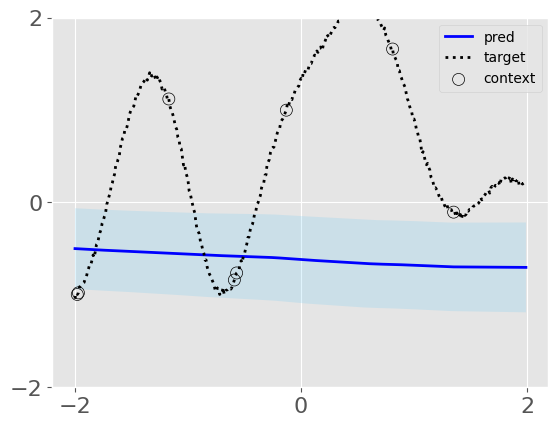

In [ ]:
for it in range(TRAINING_ITERATIONS):
  rng, data_key = jax.random.split(rng)
  data_train = dataset_train.generate_curves(data_key)

  params, opt_state, loss_value = train_step(
      params, opt_state, data_train.query, data_train.target_y)

  # Plot the predictions in `PLOT_AFTER` intervals
  if it % PLOT_AFTER == 0:
    rng, test_key = jax.random.split(rng)
    data_test = dataset_test.generate_curves(test_key)

    _, pred_y, var = model_forward(params, data_test.query)
    (context_x, context_y), target_x = data_test.query
    target_y = data_test.target_y

    print(f'\nIteration: {it}/{TRAINING_ITERATIONS}, loss: {loss_value}\n')

    # Plot the prediction and the context
    plot_functions(target_x, target_y, context_x, context_y, pred_y, var)
